In [1]:
import numpy as np 
import scipy
import h5py
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

from netneurotools.networks import struct_consensus, binarize_network

In [2]:
matlab_conns_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/raw/lexis_data/connectomes.mat"
age_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/raw/lexis_data/age.mat"
ids_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/raw/lexis_data/ids.csv"

In [15]:
conns_mat = h5py.File(matlab_conns_path)
age_mat = h5py.File(age_path)
ids_df = pd.read_csv(ids_path)

ages = np.array(age_mat["age"])[0] # .keys()

ids_df

,HCD0001305
0,HCD0008117
1,HCD0021614
2,HCD0022919
3,HCD0026119
4,HCD0029630
...,...
2413,HCA9947411
2414,HCA9953406
2415,HCA9956008
2416,HCA9986825


In [13]:
participant_groups = {}

conns = np.array(conns_mat['connectomes']).T

# Developing: Get all row indices of the rows that do not start with "HCD"
dhc_indices = ids_df[ids_df['HCD0001305'].str.startswith('HCD')].index
participant_groups["developing"] = {"indices": dhc_indices.tolist(), 
                                    "conns_array": conns[dhc_indices, :, :], 
                                    "ages": ages[dhc_indices]}
print(f"Developing: n={len(ages[dhc_indices])}, min age = {min(ages[dhc_indices])}, max age = {max(ages[dhc_indices])}")

Developing: n=635, min age = 6.0, max age = 22.0


In [ ]:
participant_groups = {}

conns = np.array(conns_mat['connectomes']).T

# Young: Get all row indices of the rows that do not start with "HC"
non_hc_indices = ids_df[~ids_df['HCD0001305'].str.startswith('HC')].index
participant_groups["young"] = {"indices": non_hc_indices.tolist(), 
                               "conns_array": conns[non_hc_indices, :, :], 
                               "ages": ages[non_hc_indices]}
print("Young:", len(non_hc_indices))

# Aging: Get all row indices of the rows that do not start with "HCA"
ahc_indices = ids_df[ids_df['HCD0001305'].str.startswith('HCA')].index
participant_groups["aging"] = {"indices": ahc_indices.tolist(), 
                               "conns_array": conns[ahc_indices, :, :], 
                               "ages": ages[ahc_indices]}
print("Aging:", len(ahc_indices))

# Developing: Get all row indices of the rows that do not start with "HCD"
dhc_indices = ids_df[ids_df['HCD0001305'].str.startswith('HCD')].index
participant_groups["developing"] = {"indices": dhc_indices.tolist(), 
                                    "conns_array": conns[dhc_indices, :, :], 
                                    "ages": ages[dhc_indices]}
print("Developing:", len(dhc_indices))

Young: 1065
Aging: 718
Developing: 635


young: n=1065, min age = 20.0, max age = 37.0
aging: n=718, min age = 28.0, max age = 100.0
developing: n=635, min age = 6.0, max age = 22.0


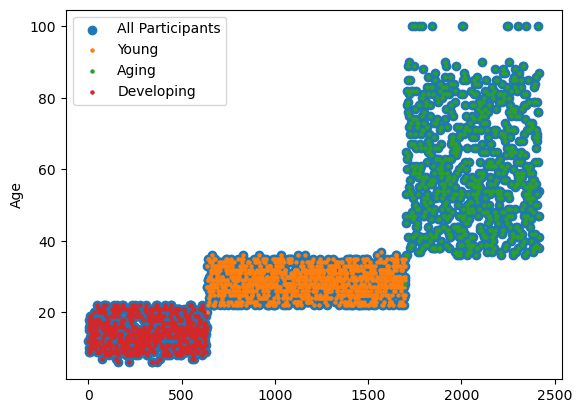

In [11]:
plt.scatter(np.arange(len(ages)), ages, label='All Participants')
for group_name, group_info in participant_groups.items():
    plt.scatter(group_info["indices"], group_info["ages"], s=5, label=f'{group_name.capitalize()}') 
    print(f"{group_name}: n={len(group_info["indices"])}, min age = {min(group_info["ages"])}, max age = {max(group_info["ages"])}")

plt.legend()
plt.ylabel("Age") 
plt.show()

In [34]:
distance_path = "/Users/adrian/Documents/01_projects/14_4D_lab/connectome_distances/data/preprocessed/lexis_data/02_distance_matrices/distance_matrix_100.npy"
d = np.load(distance_path)
d.shape

(100, 100)

In [35]:
hemiid = [0]*50 + [1]*50  # assuming 100 regions, first 50 left, next 50 right
hemiid = np.array(hemiid).reshape(-1,1)

# For all groups

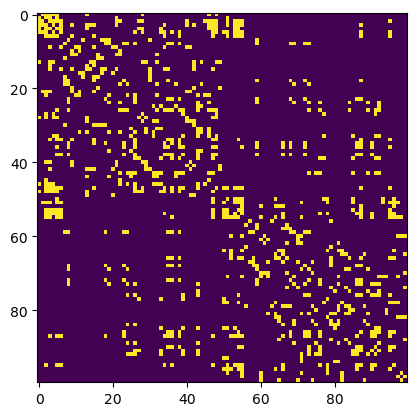

Binarized array shape (young): (1065, 100, 100)


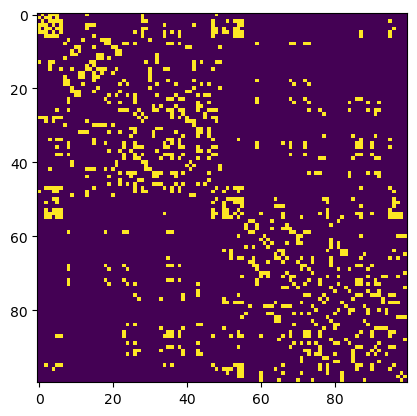

Binarized array shape (aging): (718, 100, 100)


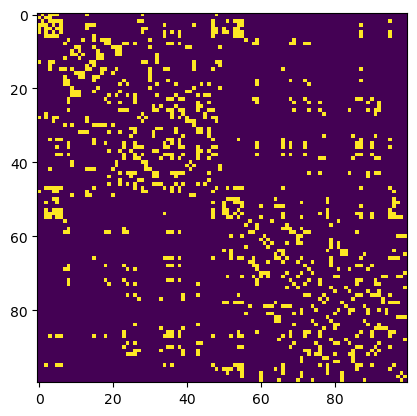

Binarized array shape (developing): (635, 100, 100)


In [37]:
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/data/preprocessed") # connectome_distances/data/preprocessed") 

for group_name, group_info in participant_groups.items():
    
    # make folder path
    dataset_folder = base_path / ("lexis_data_" + group_name) / "01_connectomes"
    dataset_folder.mkdir(parents=True, exist_ok=True)

    conns_array = group_info["conns_array"]
    consensus_non_thres = struct_consensus(conns_array.T, d, hemiid=hemiid, weighted=True) 
    consensus = binarize_network(consensus_non_thres, retain=10).reshape(-1,100,100)
    plt.imshow(consensus[0]) # , cmap='gray', interpolation='nearest')
    plt.show()
    np.save(dataset_folder / "00_connectomes_density10.npy", consensus)
    
    conns_array_binarized = [] 
    for A in conns_array: 
        conns_array_binarized.append(binarize_network(A, retain=10)) # .reshape(-1,100,100))
    conns_array_binarized = np.array(conns_array_binarized)
    print(f"Binarized array shape ({group_name}):", conns_array_binarized.shape)
    np.save(dataset_folder / "00_individual_connectomes_bin.npy", conns_array_binarized)
    
    # AGE: make folder path
    dataset_folder = base_path / ("lexis_data_" + group_name) / "04_further_info"
    dataset_folder.mkdir(parents=True, exist_ok=True)
    
    np.save(dataset_folder / "00_ages.npy", group_info["ages"])
    